In [1]:
import torch
import torch.nn.functional as F
import os
import sys
project_root = '/public/home/zhangshikang/project/decouple_detr/DecoupleDETR/'
if project_root not in sys.path:
    sys.path.insert(0, project_root)
os.chdir(project_root)
from dataset import (build_dataset, build_loader)
from models import build_model
from util.config import ConfigDict
from util.distributed import init_distributed_mode

/public/home/zhangshikang/.conda/envs/detr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/public/home/zhangshikang/.conda/envs/detr/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
check_point = '/public/home/zhangshikang/project/DATA/models/contrastive/pretrain-1-4-5-t-0.1/epoch_19.pth'
model_dict = torch.load(check_point, map_location='cuda:0',weights_only=False)
model,criterion,postprocessor = build_model(model_dict['config'])
model.load_state_dict(model_dict['model_state_dict'])

/public/home/zhangshikang/.conda/envs/detr/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/public/home/zhangshikang/.conda/envs/detr/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<All keys matched successfully>

In [3]:
cfg = ConfigDict.from_file('config/experiments/pannuke_supervised.yaml')
init_distributed_mode(cfg)
test_dataset = build_dataset(cfg, split='test')
test_loader = build_loader(cfg, test_dataset,split='test')

Not using distributed mode
loading annotations into memory...
Done (t=0.92s)
creating index...
index created!


- defining the hooks 

In [4]:
hook_output = {}
hook_input = {}
def get_attention_map(name):
    def hook(model, input, output):      
        hook_output[name] = output
        hook_input[name] = input
    return hook
model.decouple_decoder.inital_layer.cross_attn.sampling_offsets.register_forward_hook(get_attention_map('sample_offsets_0'))
for i in range(2):
    model.decouple_decoder.layers[i].cross_attn.sampling_offsets.register_forward_hook(get_attention_map(f'sampling_offsets_{i+1}'))
model.decouple_decoder.register_forward_hook(get_attention_map('decoder'))


In [5]:
model = model.to('cuda')
imgs,targets = next(iter(test_loader))
imgs = imgs.to('cuda')
model.eval()
with torch.no_grad():
    outputs = model(imgs,targets)

/public/home/zhangshikang/.conda/envs/detr/lib/python3.10/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [6]:
boxes = hook_input['decoder'][1]

In [7]:
boxes[7,:16,:]

tensor([[0.2070, 0.0586, 0.1367, 0.1133],
        [0.9492, 0.2109, 0.0938, 0.2188],
        [0.2930, 0.2812, 0.1445, 0.1641],
        [0.4336, 0.3398, 0.1250, 0.1680],
        [0.6953, 0.4258, 0.1445, 0.2734],
        [0.9336, 0.4336, 0.1211, 0.1328],
        [0.6211, 0.5859, 0.1328, 0.1797],
        [0.2227, 0.7148, 0.1094, 0.1445],
        [0.8984, 0.8945, 0.1719, 0.2031],
        [0.5977, 0.9453, 0.1445, 0.0977],
        [0.7031, 0.9844, 0.1172, 0.0234],
        [0.6289, 0.2188, 0.0703, 0.0859],
        [0.1641, 0.4844, 0.1719, 0.0859],
        [0.7500, 0.6445, 0.0938, 0.1953],
        [0.9414, 0.6836, 0.1094, 0.0898],
        [0.4375, 0.7266, 0.1016, 0.1602]], device='cuda:0')

In [8]:
boxes[7,16:,:]

tensor([[0.1600, 0.0593, 0.0864, 0.1186],
        [0.9228, 0.1729, 0.0293, 0.1518],
        [0.2576, 0.2309, 0.0662, 0.0765],
        [0.4559, 0.2926, 0.1936, 0.0919],
        [0.7224, 0.4853, 0.2242, 0.0952],
        [0.9008, 0.3888, 0.0403, 0.0763],
        [0.5929, 0.6351, 0.0686, 0.1063],
        [0.2396, 0.7375, 0.0709, 0.0946],
        [0.9334, 0.8390, 0.0747, 0.0631],
        [0.6351, 0.9306, 0.0440, 0.0525],
        [0.7314, 0.9884, 0.0522, 0.0109],
        [0.6417, 0.1933, 0.0486, 0.1280],
        [0.1149, 0.4985, 0.0532, 0.0504],
        [0.7805, 0.6009, 0.0360, 0.2729],
        [0.9649, 0.6988, 0.0589, 0.1502],
        [0.4581, 0.6952, 0.0479, 0.0529],
        [0.5000, 0.5000, 1.0000, 1.0000]], device='cuda:0')

In [9]:
instance_con = outputs['contrastive_logits'][7][:16]
anchor_con = outputs['contrastive_logits'][7][16:]
instance_pre = hook_output['decoder'][7][:16]
anchor_pre = hook_output['decoder'][7][16:]

In [10]:
cos_instance_anchor = F.cosine_similarity(instance_con.unsqueeze(1),anchor_con.unsqueeze(0),dim=-1)

In [11]:
instance_pre[1][:10]

tensor([-1.0833,  0.2476, -0.4922,  0.7103, -0.8690,  0.0210, -0.6090,  0.2489,
         0.9591,  0.4036], device='cuda:0')

In [12]:
instance_pre[3][:10]

tensor([-1.2370,  0.4705, -0.5522, -0.8221,  0.4225, -0.5436, -0.2492,  0.2261,
         0.7942,  0.4515], device='cuda:0')

In [13]:
cos_instance = F.cosine_similarity(instance_pre.unsqueeze(1),instance_pre.unsqueeze(0),dim=-1)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

In [15]:
cos = cos_instance_anchor.T.cpu().detach().clone().numpy()

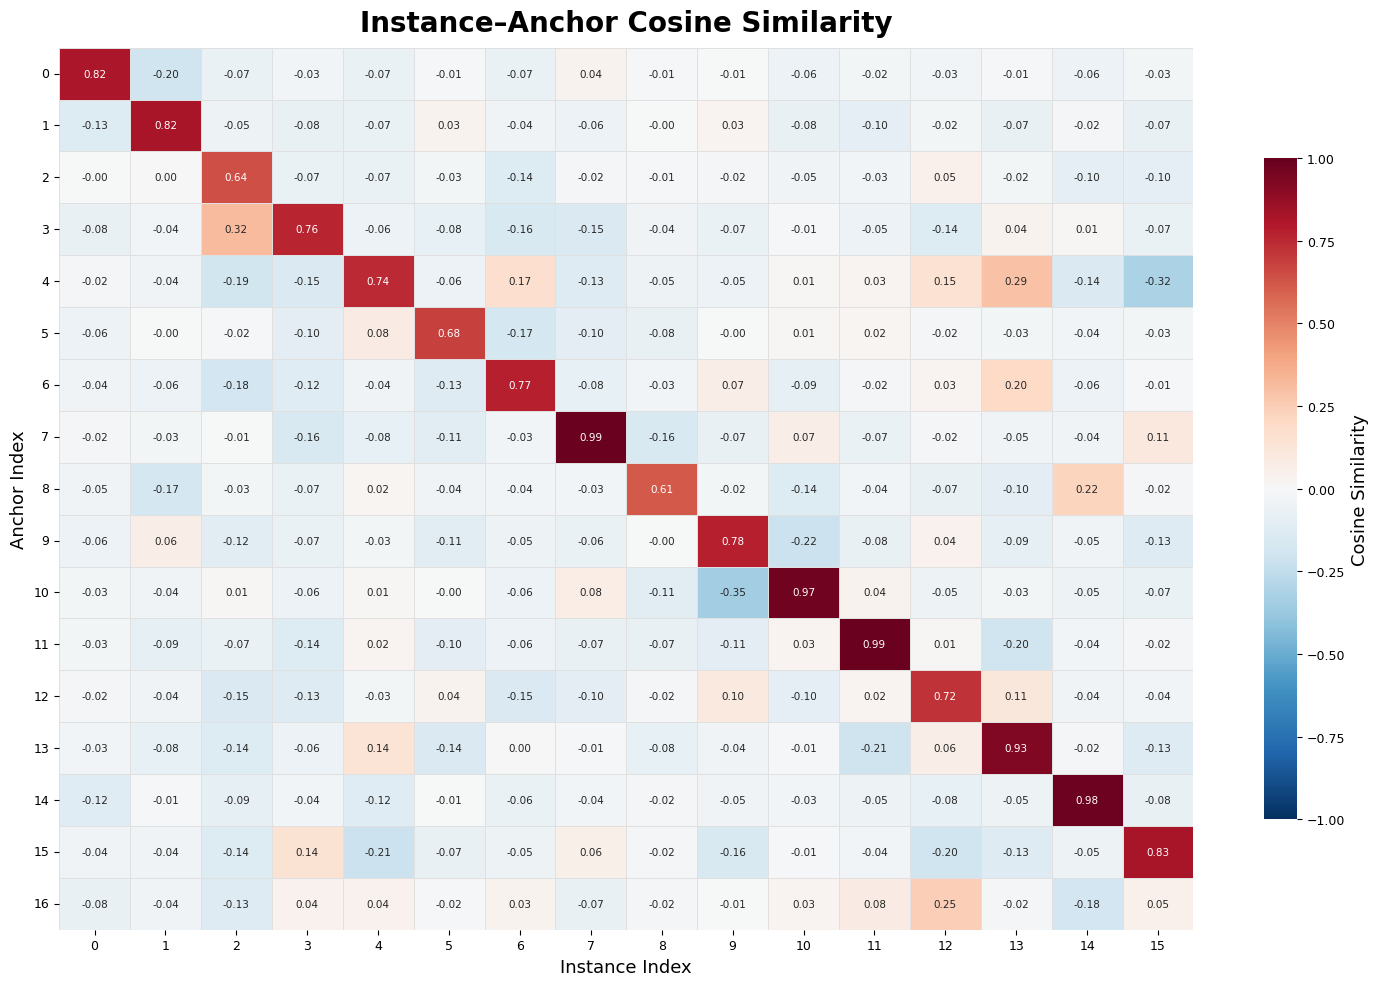

In [32]:
import matplotlib.ticker as ticker

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 20,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.linewidth': 1.0,
})

fig, ax = plt.subplots(figsize=(15, 10))
n_instance = cos.shape[1]
n_anchor   = cos.shape[0]

im = sns.heatmap(
    cos,
    annot=True, fmt='.2f', annot_kws={'size': 7.5},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='#e0e0e0',
    cbar_kws={'shrink': 0.75, 'label': 'Cosine Similarity'},
    ax=ax,
)

ax.set_title('Instance–Anchor Cosine Similarity', fontweight='bold', pad=12)
ax.set_xlabel('Instance Index')
ax.set_ylabel('Anchor Index')
ax.set_xticks(np.arange(n_instance) + 0.5)
ax.set_xticklabels(np.arange(n_instance), rotation=0)
ax.set_yticks(np.arange(n_anchor) + 0.5)
ax.set_yticklabels(np.arange(n_anchor), rotation=0)

plt.tight_layout()
plt.savefig('./instance_anchor_sim.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
cos_instance_anchor_pre = F.cosine_similarity(instance_pre.unsqueeze(1),anchor_pre.unsqueeze(0),dim=-1)

In [18]:
instance_pre[0][10:20]

tensor([ 0.0749,  0.5969, -0.3765, -1.8993,  0.8078, -1.2608,  2.0531,  0.1815,
         1.6289,  0.1097], device='cuda:0')

In [19]:
anchor_pre[0][10:20]

tensor([-0.1902,  0.8142, -0.2242, -1.6858,  0.7320, -0.8521,  1.0302, -0.1106,
         0.4576,  0.5040], device='cuda:0')

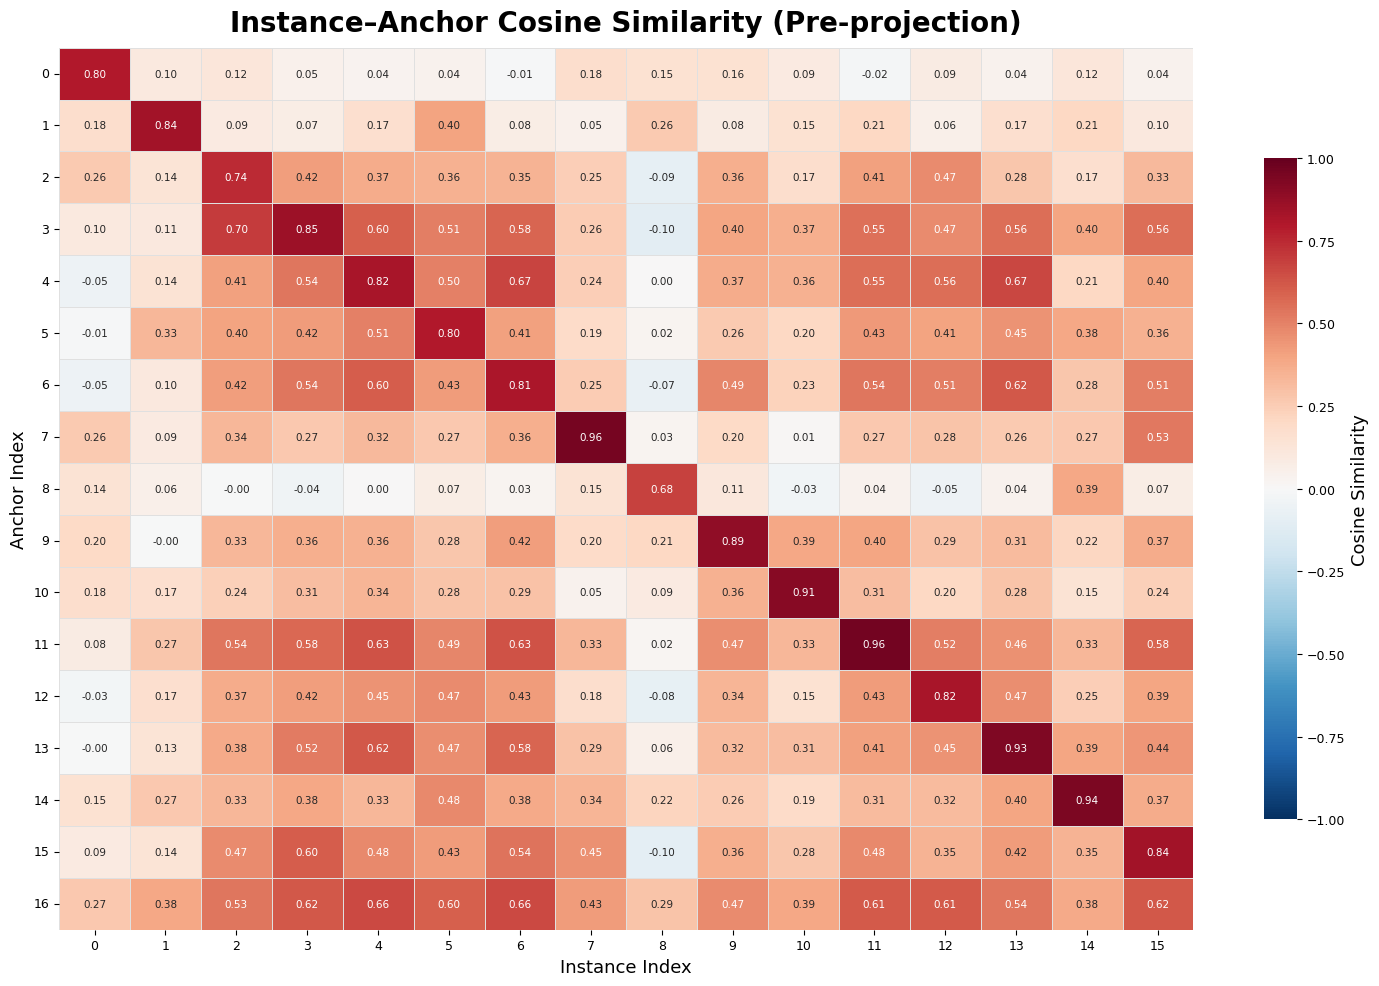

In [30]:
# cos_instance_anchor_pre = cos_instance_anchor_pre.T.cpu().detach().clone().numpy()

fig, ax = plt.subplots(figsize=(15, 10))
n_instance = cos_instance_anchor_pre.shape[1]
n_anchor   = cos_instance_anchor_pre.shape[0]

sns.heatmap(
    cos_instance_anchor_pre,
    annot=True, fmt='.2f', annot_kws={'size': 7.5},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='#e0e0e0',
    cbar_kws={'shrink': 0.75, 'label': 'Cosine Similarity'},
    ax=ax,
)

ax.set_title('Instance–Anchor Cosine Similarity (Pre-projection)', fontweight='bold', pad=12)
ax.set_xlabel('Instance Index')
ax.set_ylabel('Anchor Index')
ax.set_xticks(np.arange(n_instance) + 0.5)
ax.set_xticklabels(np.arange(n_instance), rotation=0)
ax.set_yticks(np.arange(n_anchor) + 0.5)
ax.set_yticklabels(np.arange(n_anchor), rotation=0)

plt.tight_layout()
plt.savefig('./instance_anchor_sim_pre.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
cos_instance = cos_instance.cpu().numpy()

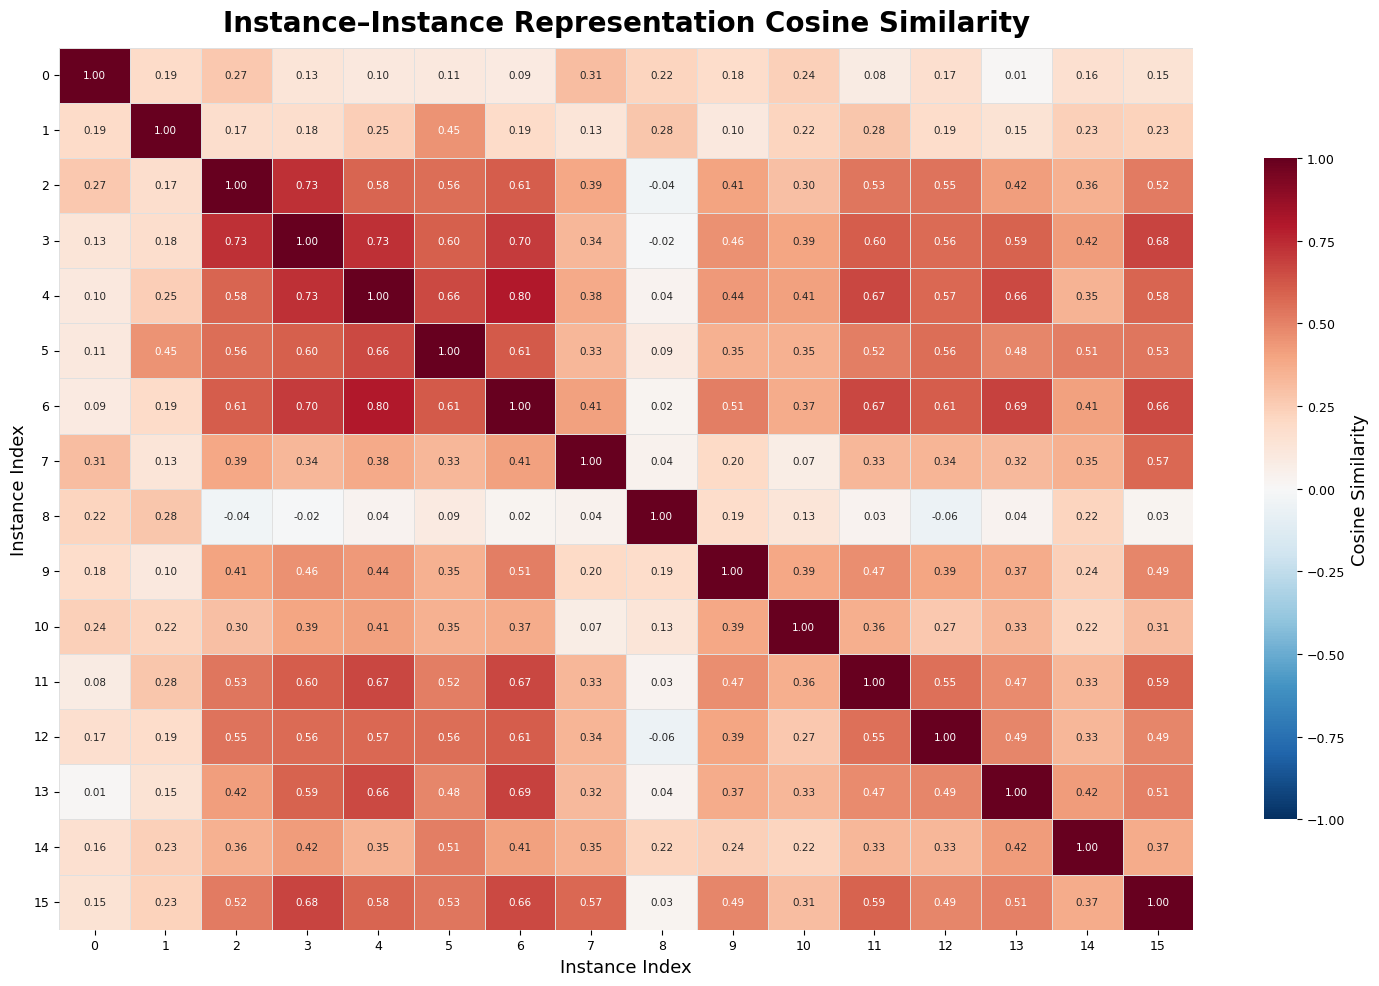

In [28]:
fig, ax = plt.subplots(figsize=(15, 10))
n = cos_instance.shape[0]

sns.heatmap(
    cos_instance,
    annot=True, fmt='.2f', annot_kws={'size': 7.5},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='#e0e0e0',
    cbar_kws={'shrink': 0.75, 'label': 'Cosine Similarity'},
    ax=ax,
)

ax.set_title('Instance–Instance Representation Cosine Similarity', fontweight='bold', pad=12)
ax.set_xlabel('Instance Index')
ax.set_ylabel('Instance Index')
ax.set_xticks(np.arange(n) + 0.5)
ax.set_xticklabels(np.arange(n), rotation=0)
ax.set_yticks(np.arange(n) + 0.5)
ax.set_yticklabels(np.arange(n), rotation=0)

plt.tight_layout()
plt.savefig('./instance_instance_sim.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
hook_output = {}
hook_input = {}
def get_attention_map(name):
    def hook(model, input, output):      
        hook_output[name] = output
        hook_input[name] = input
    return hook

In [24]:
model.decouple_decoder.inital_layer.cross_attn.sampling_offsets.register_forward_hook(get_attention_map('sample_offsets_0'))
for i in range(2):
    model.decouple_decoder.layers[i].cross_attn.sampling_offsets.register_forward_hook(get_attention_map(f'sampling_offsets_{i+1}'))

In [25]:
so_1 = hook_output['sample_offsets_0'].view(8, 33, 8, 4, 4, 2)
so_1 = so_1[0,:16,:,:,:,:]
boxes =targets[7]['boxes'].to(so_1.device)
# boxes = torch.cat(boxes,dim=0)
sp = F.tanh(so_1) * 0.5*boxes[:,None,None,None,2:]

KeyError: 'sample_offsets_0'

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


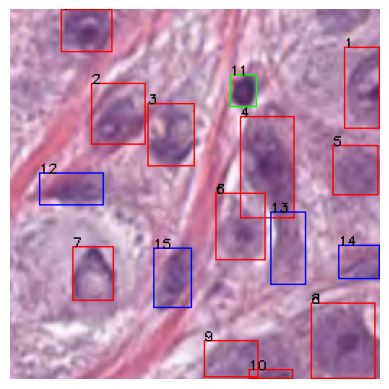

In [102]:
img = test_dataset.get_raw_image(7).numpy().transpose(1, 2, 0)
labels = targets[7]['labels']
boxes = targets[7]['boxes'].detach().cpu().numpy()
length = 16
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.3
font_thickness = 1
bg_color = (255, 255, 255) 
text_color = (0, 0, 0) 
for i in range(length):
    box = boxes[i]*256
    x1, y1 = int(box[0]-box[2]/2), int(box[1]-box[3]/2)
    x2, y2 = int(box[0]+box[2]/2), int(box[1]+box[3]/2)
    if labels[i].item() == 0:
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 1)
    elif labels[i].item() == 1:
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 1)
    else:
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 1)
    text = f'{i}'
    (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, font_thickness)
    text_x = x1
    text_y = y1
    # cv2.rectangle(
    #     img, 
    #     (int(x1), int(y1) - text_height - baseline - 5),  # 左上角
    #     (int(x1) + text_width, int(y1)),  # 右下角
    #     # bg_color, 
    #     # -1  # 填充矩形
    # )
    cv2.putText(img, text, (text_x, text_y), font, font_scale, text_color, font_thickness)
plt.axis('off')
plt.imshow(img, vmin=0, vmax=255)
    

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


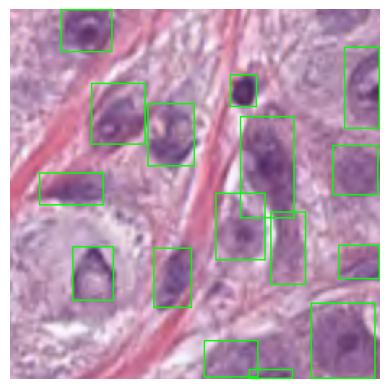

In [39]:
img = test_dataset.get_raw_image(7).numpy().transpose(1, 2, 0)
labels = targets[7]['labels']
boxes = targets[7]['boxes'].detach().cpu().numpy()
length = 16
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.3
font_thickness = 1
bg_color = (255, 255, 255) 
text_color = (0, 0, 0) 
for i in range(length):
    box = boxes[i]*256
    x1, y1 = int(box[0]-box[2]/2), int(box[1]-box[3]/2)
    x2, y2 = int(box[0]+box[2]/2), int(box[1]+box[3]/2)
    if labels[i].item() == 0:
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 1)
    elif labels[i].item() == 1:
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 1)
    else:
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 1)
    # text = f'{i}'
    # (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, font_thickness)
    # text_x = x1
    # text_y = y1
    # cv2.rectangle(
    #     img, 
    #     (int(x1), int(y1) - text_height - baseline - 5),  # 左上角
    #     (int(x1) + text_width, int(y1)),  # 右下角
    #     # bg_color, 
    #     # -1  # 填充矩形
    # )
    # cv2.putText(img, text, (text_x, text_y), font, font_scale, text_color, font_thickness)
plt.axis('off')
plt.imshow(img, vmin=0, vmax=255)
plt.savefig('image_with_boxes.png')

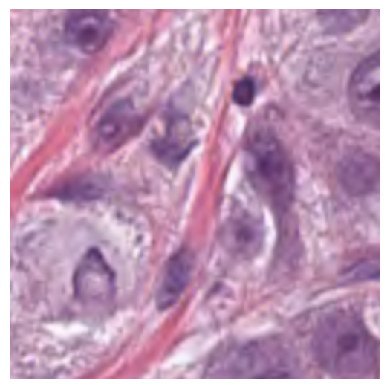

In [41]:
img = test_dataset.get_raw_image(7).numpy().transpose(1, 2, 0)
labels = targets[7]['labels']
boxes = targets[7]['boxes'].detach().cpu().numpy()
length = 16
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.3
font_thickness = 1
bg_color = (255, 255, 255) 
text_color = (0, 0, 0) 
# for i in range(length):
#     box = boxes[i]*256
#     x1, y1 = int(box[0]-box[2]/2), int(box[1]-box[3]/2)
#     x2, y2 = int(box[0]+box[2]/2), int(box[1]+box[3]/2)
#     if labels[i].item() == 0:
#         cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 1)
#     elif labels[i].item() == 1:
#         cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 1)
#     else:
#         cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 1)
    # text = f'{i}'
    # (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, font_thickness)
    # text_x = x1
    # text_y = y1
    # cv2.rectangle(
    #     img, 
    #     (int(x1), int(y1) - text_height - baseline - 5),  # 左上角
    #     (int(x1) + text_width, int(y1)),  # 右下角
    #     # bg_color, 
    #     # -1  # 填充矩形
    # )
    # cv2.putText(img, text, (text_x, text_y), font, font_scale, text_color, font_thickness)
plt.axis('off')
plt.imshow(img, vmin=0, vmax=255)
plt.savefig('image_with_no_boxes.png')

### test noise adding

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


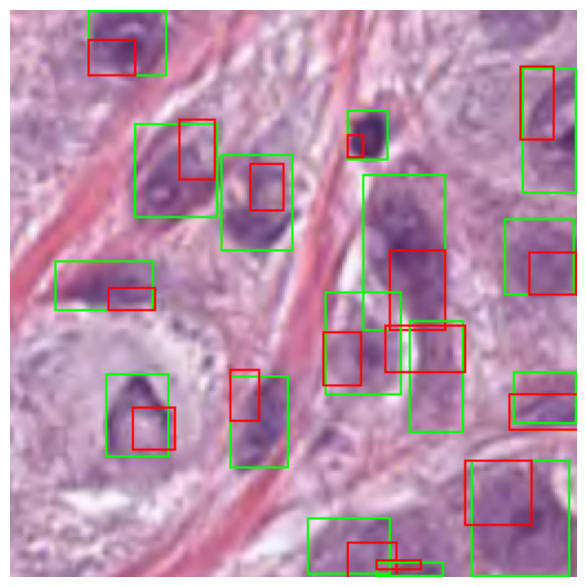

In [56]:
from models.decouple_detr.decouple_detr import get_noised_boxes

img_idx = 7
img = test_dataset.get_raw_image(img_idx).numpy().transpose(1, 2, 0).copy()
gt_boxes = targets[img_idx]['boxes'].detach().cpu()
labels = targets[img_idx]['labels'].detach().cpu().numpy()

noised_boxes = get_noised_boxes(
    scale_n_l=0.3, scale_n_u=0.6,
    positive_negative_ratio=0.2,
    ground_truth=gt_boxes,
    noise_percentage=1,
).numpy()
gt_boxes_np = gt_boxes.numpy()

H, W = img.shape[:2]
font = cv2.FONT_HERSHEY_SIMPLEX

for i in range(len(gt_boxes_np)):
    # ground truth box (green)
    box = gt_boxes_np[i] * np.array([W, H, W, H])
    x1, y1 = int(box[0] - box[2] / 2), int(box[1] - box[3] / 2)
    x2, y2 = int(box[0] + box[2] / 2), int(box[1] + box[3] / 2)
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 1)

    # noisy box (red)
    nbox = noised_boxes[i] * np.array([W, H, W, H])
    nx1, ny1 = int(nbox[0] - nbox[2] / 2), int(nbox[1] - nbox[3] / 2)
    nx2, ny2 = int(nbox[0] + nbox[2] / 2), int(nbox[1] + nbox[3] / 2)
    cv2.rectangle(img, (nx1, ny1), (nx2, ny2), (255, 0, 0), 1)

    # cv2.putText(img, str(i), (x1, max(y1 - 2, 8)), font, 0.3, (0, 200, 0), 1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, vmin=0, vmax=255)
ax.axis('off')
# ax.set_title('Green: GT boxes    Red: Noisy boxes')
plt.tight_layout()
plt.savefig('noise_boxes_vis.png', dpi=150, bbox_inches='tight')
plt.show()


In [50]:
img = test_dataset.get_raw_image(0).numpy().transpose(1, 2, 0)
labels = targets[7]['labels']
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.3
font_thickness = 1
bg_color = (255, 255, 255) 
text_color = (0, 0, 0) 
anchor_index = 18
cos_matrix = F.cosine_similarity(instance.unsqueeze(1),instance.unsqueeze(0),dim=-1)[anchor_index]
length = 16
for i in range(length):
    box = boxes[i].detach().cpu().numpy()*256
    x1, y1 = int(box[0]-box[2]/2), int(box[1]-box[3]/2)
    x2, y2 = int(box[0]+box[2]/2), int(box[1]+box[3]/2)
    if i == anchor_index:
        cv2.rectangle(img, (int(x2),int(y2)), (int(x1),int(y1)), (0,0,255), 1)
    else:
        cv2.rectangle(img, (int(x2),int(y2)), (int(x1),int(y1)), (0,255,0), 1)
    text = f'{labels[i]}:{cos_matrix[i]:.2f}'
    (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, font_thickness)
    text_x = x1
    text_y = y1
    cv2.rectangle(
        img, 
        (int(x1), int(y1) - text_height - baseline - 5),  # 左上角
        (int(x1) + text_width, int(y1)),  # 右下角
        bg_color, 
        -1  # 填充矩形
    )
    cv2.putText(img, text, (text_x, text_y), font, font_scale, text_color, font_thickness)
    point = (box[:2] + sp[i].view(-1, 2).detach().cpu().numpy()*256).astype(int)
    atten_map = atten[0][i].view(-1).detach().cpu().numpy()
    for k,j in enumerate(point):
        if atten_map[k] > 0.1:
            cv2.circle(img, (j[0], j[1]), 1, (255,0,0), -1)
plt.imshow(img)

NameError: name 'instance' is not defined